In [4]:
from cytograph import Algorithm, creates, requires, div0
from cytograph.visualization.scatter import scatterc, scattern
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from typing import List
import shoji
import cytograph as cg
import cytograph.visualization as cgplot
import collections
from typing import List, Optional
import matplotlib.patheffects as PathEffects
import fastcluster
import igraph
import leidenalg as la
import scipy.cluster.hierarchy as hc
from hmmlearn import hmm
from openTSNE import TSNE
from pynndescent import NNDescent
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from tqdm import trange
import pandas as pd
from cytograph.visualization import Colorizer
from matplotlib.lines import Line2D
import scanpy as sc
import loompy
import infercnvpy as cnv
warnings.filterwarnings('ignore')
import warnings

In [5]:
#Connect to database
db = shoji.connect()

In [3]:
# Create a test workspace, and a subworkspace for holding an example dataset
#db.builds.jesper.h5ad = shoji.Workspace()
db.builds.jesper.h5ad.GBM_SL040 = shoji.Workspace()
ws = db.builds.jesper.h5ad.GBM_SL040

In [63]:
# Load the sample data into your local Shoji database
ad = sc.read_h5ad('/proj/cytograph/jesper/GBM_revision/h5ad/SL040.h5ad')
ws.import_adata(ad, verbose=True)


KeyboardInterrupt



In [98]:
#view
ad = sc.read_h5ad('/proj/cytograph/jesper/GBM_revision/h5ad/SL040.h5ad')
ad

AnnData object with n_obs × n_vars = 135482 × 59480
    obs: 'CellCycleFraction', 'Chemistry', 'Clusters', 'ClustersProbability', 'ClustersSecondary', 'ClustersSecondaryProbability', 'Direction', 'DoubletFlag', 'DoubletScore', 'Fluorescence', 'Location', 'ManualAnnotationSL040_TAM', 'ManualAnnotationSL040_central_peri', 'MitoFraction', 'NGenes', 'NeftelClass', 'Sample', 'SampleID', 'SignatureBootstrap', 'TotalUMIs', 'UnsplicedFraction', 'ValidCells', 'Zone', 'Aneuploid', 'ManualAnnotationSL040', 'ManualAnnotationSL040_Myeloid'
    var: 'Chromosome', 'End', 'Gene', 'GeneNonzeros', 'GeneTotalUMIs', 'SelectedFeatures', 'Start', 'StdevExpression', 'ValidGenes', 'Accession'
    obsm: 'Embedding', 'Factors'
    layers: 'Expression'

In [ ]:
#Change "astype"
Gene = np.array(ad.var.Gene)

In [ ]:
ws.Gene = shoji.Tensor(dtype='string', dims=('genes',), inits=Gene.astype('object'))

In [8]:
Exp = ws.Expression[:]

In [9]:
ws.Expression = shoji.Tensor(dtype='uint16', dims=('cells', 'genes'), inits=Exp.astype('uint16'))

In [29]:
Emb = ad.obsm['Embedding']

In [30]:
ws.Embedding = shoji.Tensor(dtype='float32', dims=('cells', 2), inits=Emb.astype('float32'))

In [ ]:
ad

AnnData object with n_obs × n_vars = 135482 × 59480
    obs: 'CellCycleFraction', 'Chemistry', 'Clusters', 'ClustersProbability', 'ClustersSecondary', 'ClustersSecondaryProbability', 'Direction', 'DoubletFlag', 'DoubletScore', 'Fluorescence', 'Location', 'ManualAnnotationSL040_TAM', 'ManualAnnotationSL040_central_peri', 'MitoFraction', 'NGenes', 'NeftelClass', 'Sample', 'SampleID', 'SignatureBootstrap', 'TotalUMIs', 'UnsplicedFraction', 'ValidCells', 'Zone', 'Aneuploid', 'ManualAnnotationSL040', 'ManualAnnotationSL040_Myeloid'
    var: 'Chromosome', 'End', 'Gene', 'GeneNonzeros', 'GeneTotalUMIs', 'SelectedFeatures', 'Start', 'StdevExpression', 'ValidGenes', 'Accession'
    obsm: 'Embedding', 'Factors', 'X_tsne'
    layers: 'Expression'

# Analyze multi-region SL40

## Figure 1

### Colors of choice (Fig 1a)

In [ ]:
palette_classes = {'Astrocytes':'#4574b3',
 'B-cells': [0.0, 0.45703125, 0.859375],
 'Endothelial': [0.59765625, 0.24609375, 0.0],
 'Fibroblasts': [0.296875, 0.0, 0.359375],
 'Macrophages': "#c7bd80",
 'Microglia': "#ee7c0e",
 'MoTAM': [0.99609375, 0.796875, 0.59765625], 
 'MgTAM':  "#b36305",                
 'Monocytes': "#a580ad",
 'OPCs': [0.55859375, 0.484375, 0.0],
 'Oligodendrocytes': "#000000",
 'Pericytes': [0.7578125, 0.0, 0.53125],
 'Tumor': "#74c493",
 'VSMC': [0.99609375, 0.640625, 0.01953125]}

In [54]:
annotation_palette = {
'Astrocytes': '#4574B3',#'#3fc380',
'Oligodendrocytes':'#000000',

'B-cells': '#808080',
'Endothelial':'#808080',#'#fef160',
'Fibroblasts':'#808080',
'NK, T-cells':'#808080',
'OPCs':'#808080',
'Pericytes':'#808080',
'VSMC':'#808080',

'MgTAM':'#B36305',#'#d2d7d3',
'MoTAM':'#FECB98',#'#d
'Microglia':'#EE7C0E',
'Monocytes':'#A580AD',
'Neuron':'#fabe58',
'Macrophages':'#C7BD80',

'Tumor':'#74C493',#'#e76d89',
}

### tSNE Fig 1a

In [51]:
ad.obsm["X_tsne"] =ad.obsm["Embedding"]

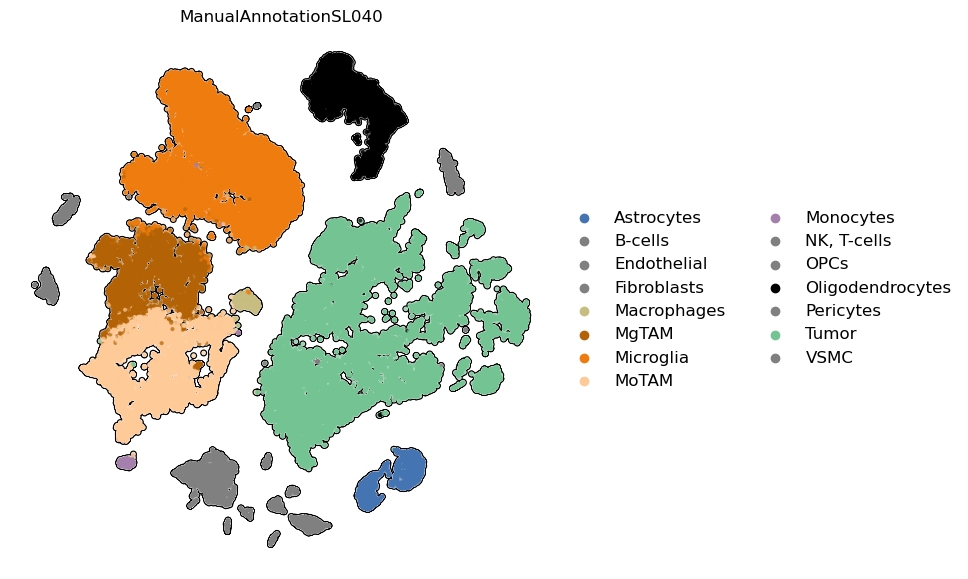

In [ ]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(7,7))

sc.pl.tsne(
ad,
color='ManualAnnotationSL040',
add_outline=True,
size=35,
legend_fontsize=12,
legend_fontoutline=2,
frameon=False,
palette=annotation_palette,
ax=ax,
show=False,
)
plt.show()

### Calc fraction of cell types (fig 1a)

CPU times: user 8.2 s, sys: 2.22 s, total: 10.4 s
Wall time: 13.6 s


[Text(0, 0, 'SL040_cortex'),
 Text(0, 1, 'SL040_periphery'),
 Text(0, 2, 'SL040_low'),
 Text(0, 3, 'SL040_high'),
 Text(0, 4, 'SL040_core')]

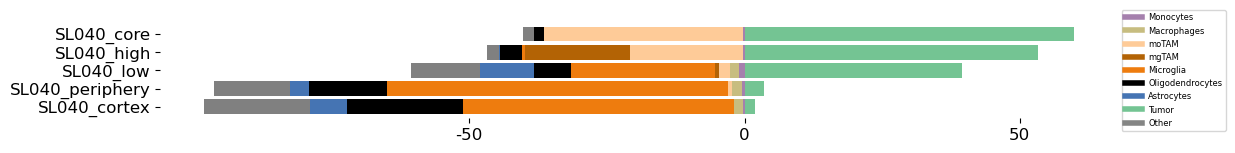

In [71]:
%%time
S = []
Samples = ['Necrotic core', 'High', 'Low', 'Periphery', 'Cortex']
unique_samples = ['SL040_core', 'SL040_high', 'SL040_low', 'SL040_periphery', 'SL040_cortex']
unique_samples = np.flip(unique_samples)
Samples = np.flip(Samples)
Samples = np.array(Samples, dtype=object)
unique_samples = np.array(unique_samples, dtype=object)
labels = np.unique(ws.ManualAnnotationSL040[:])
for i, sample in enumerate(Samples):
    Man = ws.ManualAnnotationSL040[:][ws.Fluorescence[:] == sample]
    Sum = []
    for x in labels:
        Sum.append(np.sum(np.isin(Man, x)))
    Percent = []
    tot = np.sum(Sum)
    for x in Sum:
        roundedNumber = round(x/tot * 100, 3)
        Perc = str(roundedNumber) + "%"
        Percent.append(roundedNumber)
    size = np.array(Percent)
    S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
nontumor_bars = df.drop(['B-cells','Endothelial','Fibroblasts','NK, T-cells','OPCs','Pericytes','VSMC','Tumor'], axis=1)
other_bars = df[['B-cells','Endothelial','Fibroblasts','NK, T-cells','OPCs','Pericytes','VSMC']]
tumor_bars = df[["Tumor"]]
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(10, 1.25))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([-50,0,50])
ax1.xaxis.set_visible(True)
ax1.set_xticklabels([-50,0,50],fontsize=12)

for i, ct in enumerate(Right_order):
    ax1.barh(unique_samples,height=0.8, width=-nontumor_bars[ct],left=-left, color=palette_classes[ct])
    left += nontumor_bars[ct]
for i, ct in enumerate(other_bars):
    ax1.barh(unique_samples,height=0.8, width=-other_bars[ct],left=-left, color=[0.5, 0.5, 0.5])
    left += other_bars[ct]
for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=palette_classes[ct])
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in Z]
ax1.legend(hidden_lines,labels2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12)

### Calc fraction of MES-type tumor cells (Fig 1a)

CPU times: user 8.27 s, sys: 2.29 s, total: 10.6 s
Wall time: 13.8 s


[Text(0, 0, 'SL040_cortex'),
 Text(0, 1, 'SL040_periphery'),
 Text(0, 2, 'SL040_low'),
 Text(0, 3, 'SL040_high'),
 Text(0, 4, 'SL040_core')]

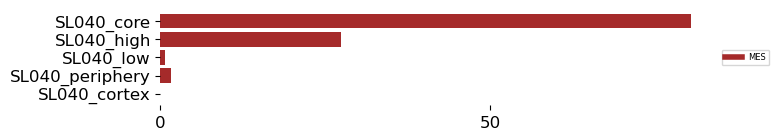

In [58]:
%%time
S = []
Samples = ['Necrotic core', 'High', 'Low', 'Periphery','Cortex']
unique_samples = ['SL040_core', 'SL040_high', 'SL040_low', 'SL040_periphery', 'SL040_cortex']
Samples = np.array(Samples, dtype=object)
Samples = np.flip(Samples)
unique_samples = np.array(unique_samples, dtype=object)
unique_samples = np.flip(unique_samples)
A = ['AC', 'MES', 'NPC', 'OPC']
labels = np.array(A, dtype=object)
for i, sample in enumerate(Samples):
    ac, mes, npc, opc = np.hsplit(ws.NeftelScore[ws.Fluorescence[:] == sample][ws.ManualAnnotationSL040[ws.Fluorescence[:] == sample] == 'Tumor'], 4)
    winnersAll = np.argmax([ac, mes, npc, opc], axis=0)
    Man = np.hstack(labels[winnersAll])
    Sum = []
    for x in labels:
        Sum.append(np.sum(np.isin(Man, x)))
    Percent = []
    tot = np.sum(Sum)
    for x in Sum:
        roundedNumber = round(x/tot * 100, 3)
        Perc = str(roundedNumber) + "%"
        Percent.append(roundedNumber)
    size = np.array(Percent)
    S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
nontumor_bars = df.drop('MES', axis=1)
tumor_bars = df[["MES"]]
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(6, len(Samples)*0.25))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([-50,0,50])
ax1.xaxis.set_visible(True) 

ax1.set_xticklabels([-50,0,50],fontsize=12)
colors=["brown"]
labels = ['MES']
labels = np.array(labels, dtype=object)
pcolors = dict(zip(labels, colors))

for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=pcolors[ct])
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in colors]
ax1.legend(hidden_lines,labels, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12) 

### Calc cell cycle fraction in tumor cells (Fig 1a)

CPU times: user 16.3 s, sys: 4.46 s, total: 20.8 s
Wall time: 27.2 s


[Text(0, 0, 'SL040_cortex'),
 Text(0, 1, 'SL040_periphery'),
 Text(0, 2, 'SL040_low'),
 Text(0, 3, 'SL040_high'),
 Text(0, 4, 'SL040_core')]

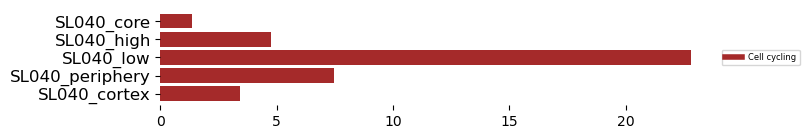

In [70]:
%%time
S = []
Samples = ['Necrotic core', 'High', 'Low', 'Periphery','Cortex']
unique_samples = ['SL040_core', 'SL040_high', 'SL040_low', 'SL040_periphery', 'SL040_cortex']
Samples = np.array(Samples, dtype=object)
Samples = np.flip(Samples)
unique_samples = np.array(unique_samples, dtype=object)
unique_samples = np.flip(unique_samples)
for i, sample in enumerate(Samples):
    Man = np.sum(ws.CellCycleFraction[ws.Fluorescence[:] == sample][ws.ManualAnnotationSL040[ws.Fluorescence[:] == sample] == 'Tumor'] > 0.004)
    tot = len(ws.CellCycleFraction[ws.Fluorescence[:] == sample][ws.ManualAnnotationSL040[ws.Fluorescence[:] == sample] == 'Tumor'])
    roundedNumber = round(Man/tot * 100, 3)
    Perc = str(roundedNumber) + "%"
    S.append(roundedNumber)
tumor_bars = pd.DataFrame(S, index=unique_samples)
tumor_bars = tumor_bars.rename(columns={0: 'Cell cycling'})
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(6, len(Samples)*0.25))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.xaxis.set_visible(True) 

colors=["brown"]
labels = ['Cell cycling']
labels = np.array(labels, dtype=object)
pcolors = dict(zip(labels, colors))

for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=pcolors[ct])
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in colors]
ax1.legend(hidden_lines,labels, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12) 

### Full list of MES1 and MES2 genes (concatenated)

In [8]:
MES1 = np.array(["CHI3L1","ANXA2","ANXA1","CD44","VIM","MT2A","C1S","NAMPT","EFEMP1","C1R","SOD2","IFITM3","TIMP1","SPP1","A2M","S100A11","MT1X","S100A10","FN1","LGALS1","S100A16","CLIC1","MGST1","RCAN1","TAGLN2","NPC2","SERPING1","TCIM","EMP1","APOE","CTSB","C3","LGALS3","MT1E","EMP3","SERPINA3","ACTN1","PRDX6","IGFBP7","SERPINE1","PLP2","MGP","CLIC4","GFPT2","GSN","NNMT","TUBA1C","GJA1","TNFRSF1A","WWTR1"])
MES2 = np.array(["HILPDA","ADM","DDIT3","NDRG1","HERPUD1","DNAJB9","TRIB3","ENO2","AKAP12","SQSTM1","MT1X","ATF3","NAMPT","NRN1","SLC2A1","BNIP3","LGALS3","INSIG2","IGFBP3","PPP1R15A","VIM","PLOD2","GBE1","SLC2A3","FTL","WARS1","ERO1A","XPOT","HSPA5","GDF15","ANXA2","EPAS1","LDHA","P4HA1","SERTAD1","PFKP","PGK1","EGLN3","SLC6A6","CA9","BNIP3L","RPL21","TRAM1","UFM1","ASNS","GOLT1B","ANGPTL4","SLC39A14","CDKN1A","HSPA9"])
gene_list = np.concatenate((MES1, MES2))
_, i = np.unique(gene_list, return_index=True)
gene_list = gene_list[np.sort(i)]

### Colormap for relevant cell types across all MES-genes and zones (Fig 1b)

CPU times: user 1h 11min 8s, sys: 19min 14s, total: 1h 30min 22s
Wall time: 1h 59min 49s


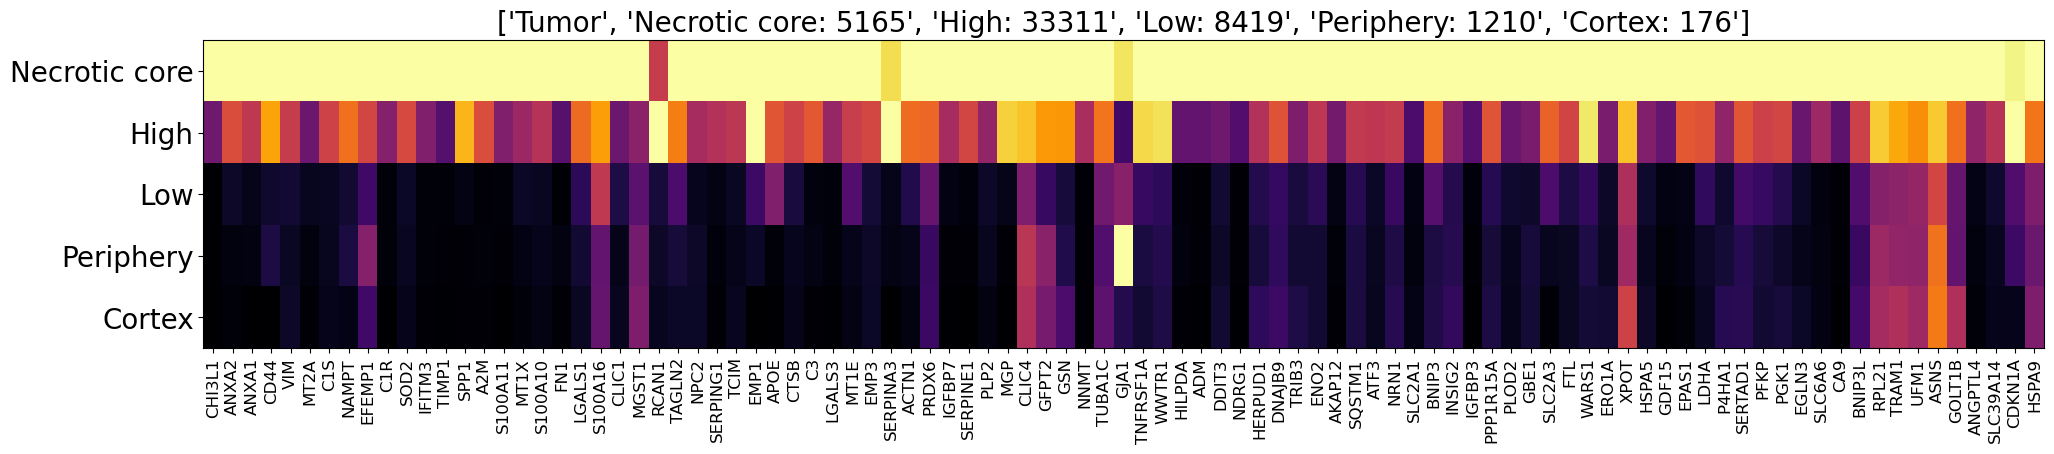

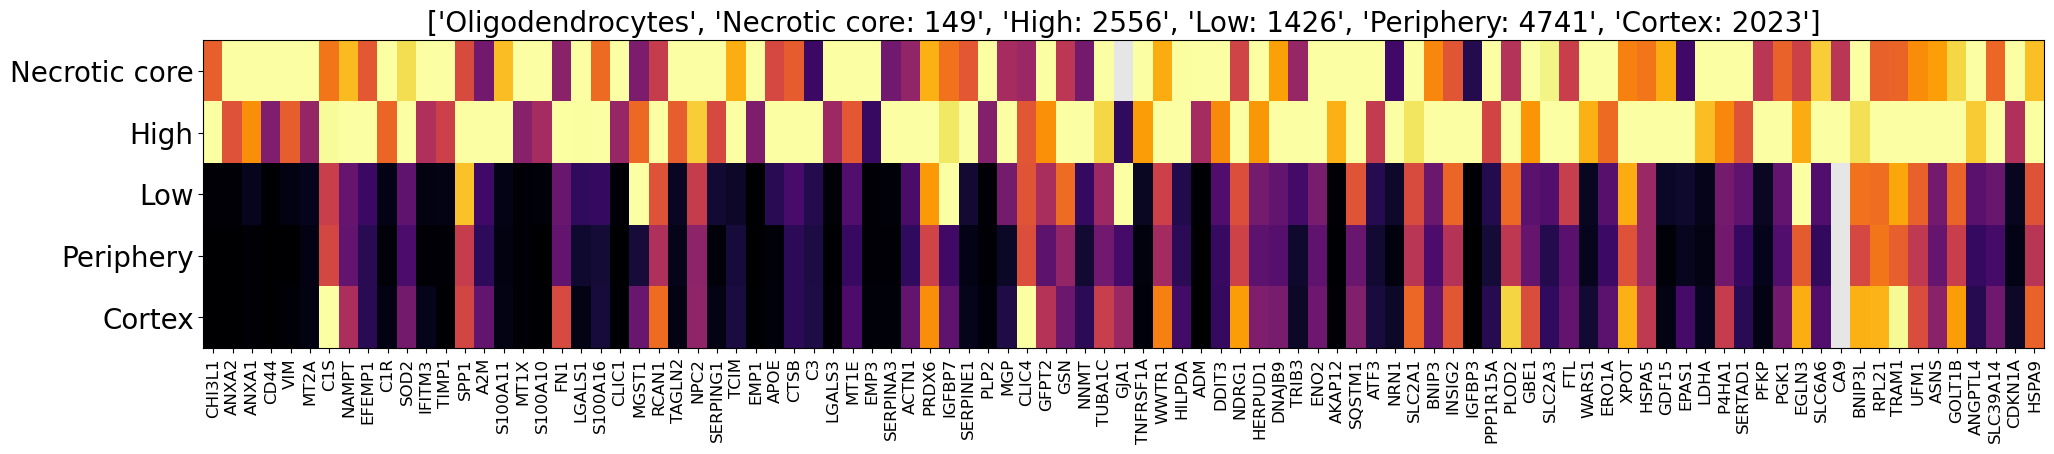

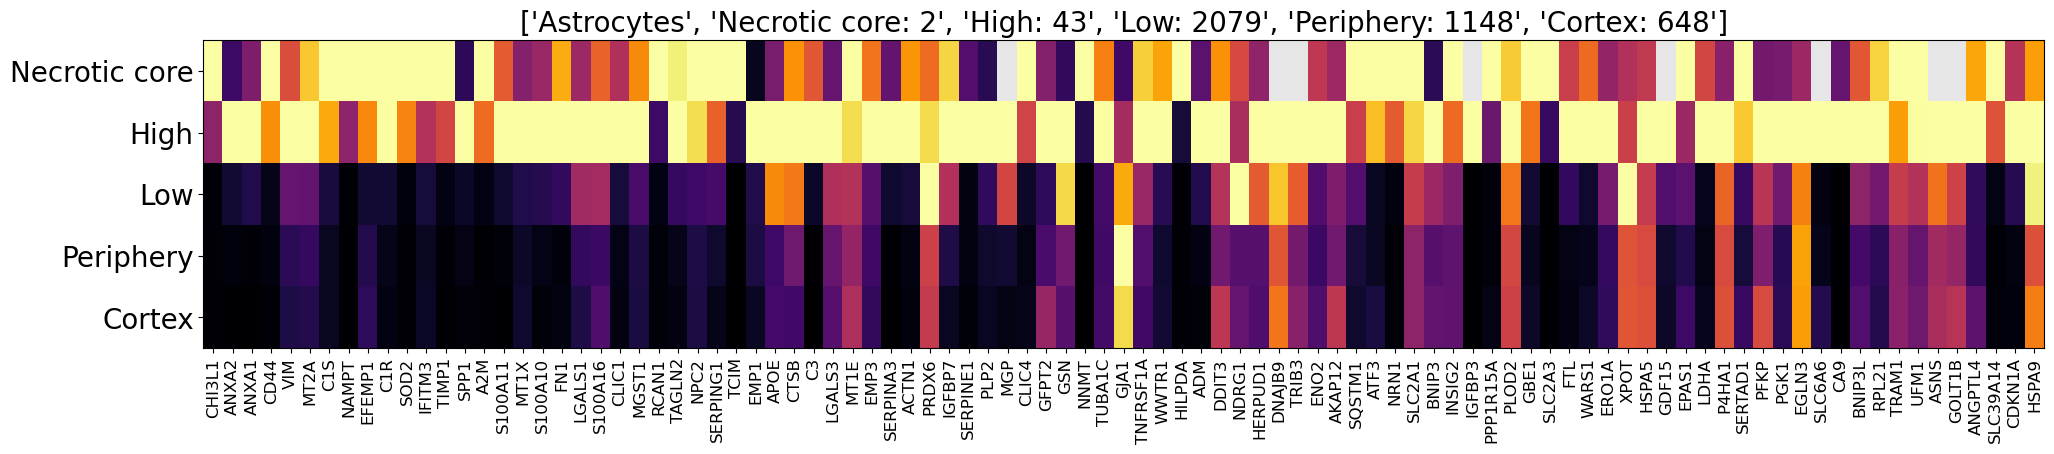

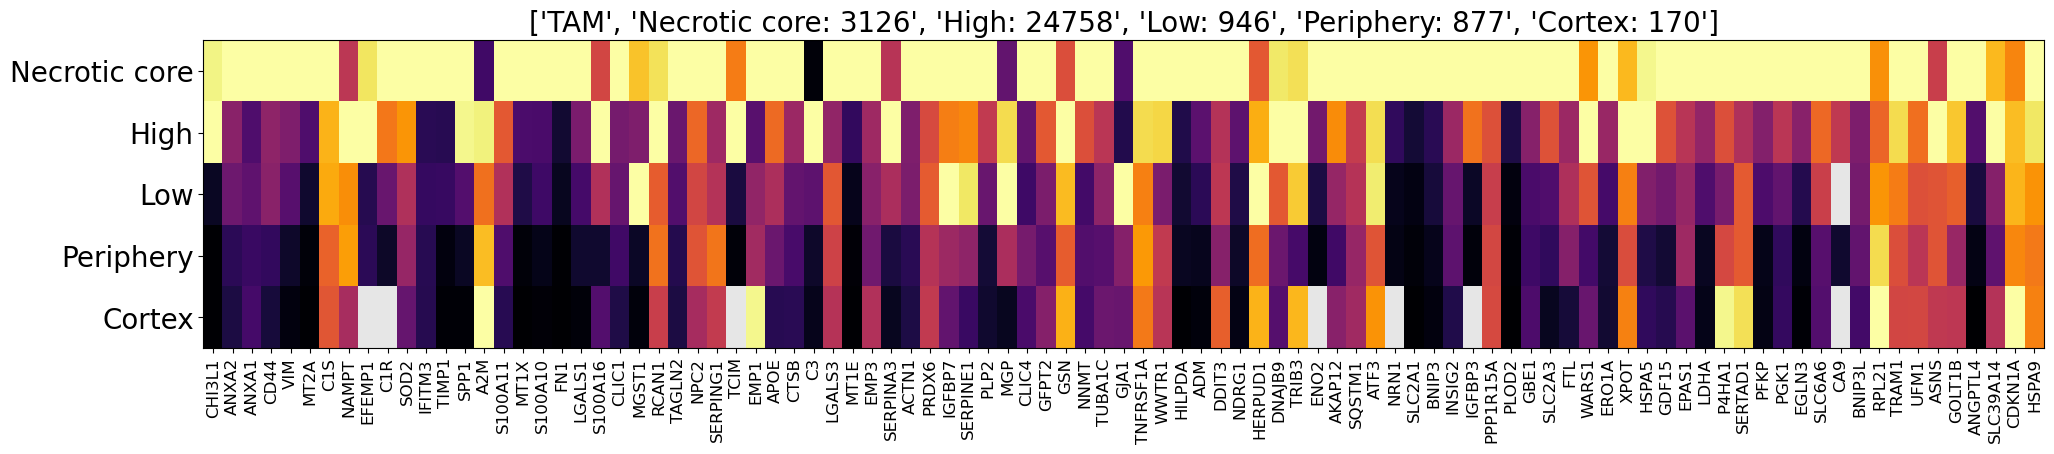

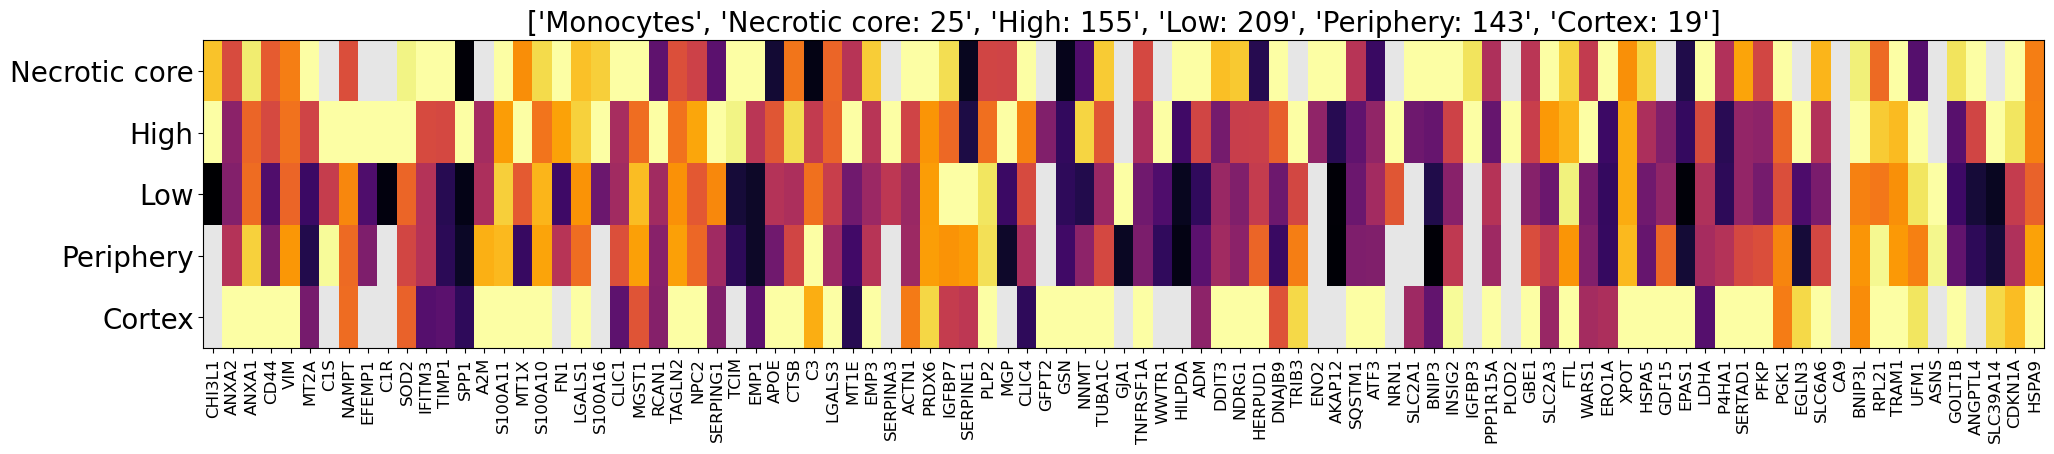

In [85]:
%%time
#Heatmap for all cell types, normalized internally. Print number of cells on top
celltype = ['Tumor', 'Oligodendrocytes', 'Astrocytes', 'TAM', 'Monocytes']
Samples = ['Necrotic core', 'High', 'Low', 'Periphery', 'Cortex']
Samples = np.array(Samples, dtype=object)
for cell in celltype:
    Sum = [cell]
    unique_samples = []
    for i, sample in enumerate(Samples):
        Su = np.sum(ws.ManualAnnotationSL040_TAM[ws.Fluorescence[:] == sample] == cell)
        Sum.append(sample + ": " + str(Su))
        if Su > 0:
            unique_samples.append(sample)
    n_genes = len(gene_list)
    n_clusters = len(unique_samples)
    x = np.zeros((n_genes, n_clusters))
    for i, gene in enumerate(gene_list):
        gene_ix = np.where(ws.Gene[:] == gene)[0][0]
        for n, sample in enumerate(unique_samples):
            x[i, n] = np.mean(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == sample][ws.ManualAnnotationSL040_TAM[ws.Fluorescence[:] == sample] == cell])

    # Normalize
    totals = x.sum(axis=1)
    xY = (x.T / totals * np.median(totals)).T
    xY = cg.div0(xY.T, np.percentile(xY, 99.5, axis=1)).T

    # Make background grey for zeros
    xY = xY.T
    G = xY
    bg = np.zeros_like(xY) + 0.9
    xY = np.ma.masked_where(xY == 0, xY)
    plt.figure(None, (n_genes / 4, 4))
    plt.imshow(bg[:], vmin=0, vmax=1, cmap=plt.cm.gray, aspect="auto")
    plt.imshow(xY[:], cmap="inferno", vmax=1, interpolation= "nearest", aspect="auto", alpha=1)
    plt.xticks(ticks=range(n_genes),labels=gene_list, fontsize=12, rotation=90)
    plt.yticks(ticks=range(n_clusters), labels=unique_samples, fontsize=20)
    plt.title(list(Sum),fontsize=20)
    None


## Extended figure 1

### Heatmap of the inferred CNV profiles (Extended fig 1c)

In [89]:
ad.var_names_make_unique()

In [92]:
ad.var["chromosome"] = ad.var["Chromosome"]
ad.var["start"] = ad.var["Start"]
ad.var["end"] = ad.var["End"]
ad.var["ensg"] = ad.var["Accession"]

In [94]:
#Normalize and logaritmize
sc.pp.normalize_total(ad)
sc.pp.log1p(ad)

In [ ]:
cnv.tl.infercnv(ad, window_size=500, exclude_chromosomes=('', 'GL000009.2', 'GL000194.1', 'GL000195.1', 'GL000205.2',
       'GL000213.1', 'GL000216.2', 'GL000218.1', 'GL000219.1',
       'GL000220.1', 'GL000225.1', 'KI270442.1', 'KI270711.1',
       'KI270713.1', 'KI270721.1', 'KI270726.1', 'KI270727.1',
       'KI270728.1', 'KI270731.1', 'KI270733.1', 'KI270734.1',
       'KI270744.1', 'KI270750.1','chrM','chrY'), reference_key="ManualAnnotationSL040",reference_cat=["Astrocytes", "Microglia","MgTAM", "Oligodendrocytes", "Endothelial"])

{'heatmap_ax': <Axes: >,
 'groupby_ax': <Axes: ylabel='Aneuploid'>,
 'gene_groups_ax': <Axes: >}

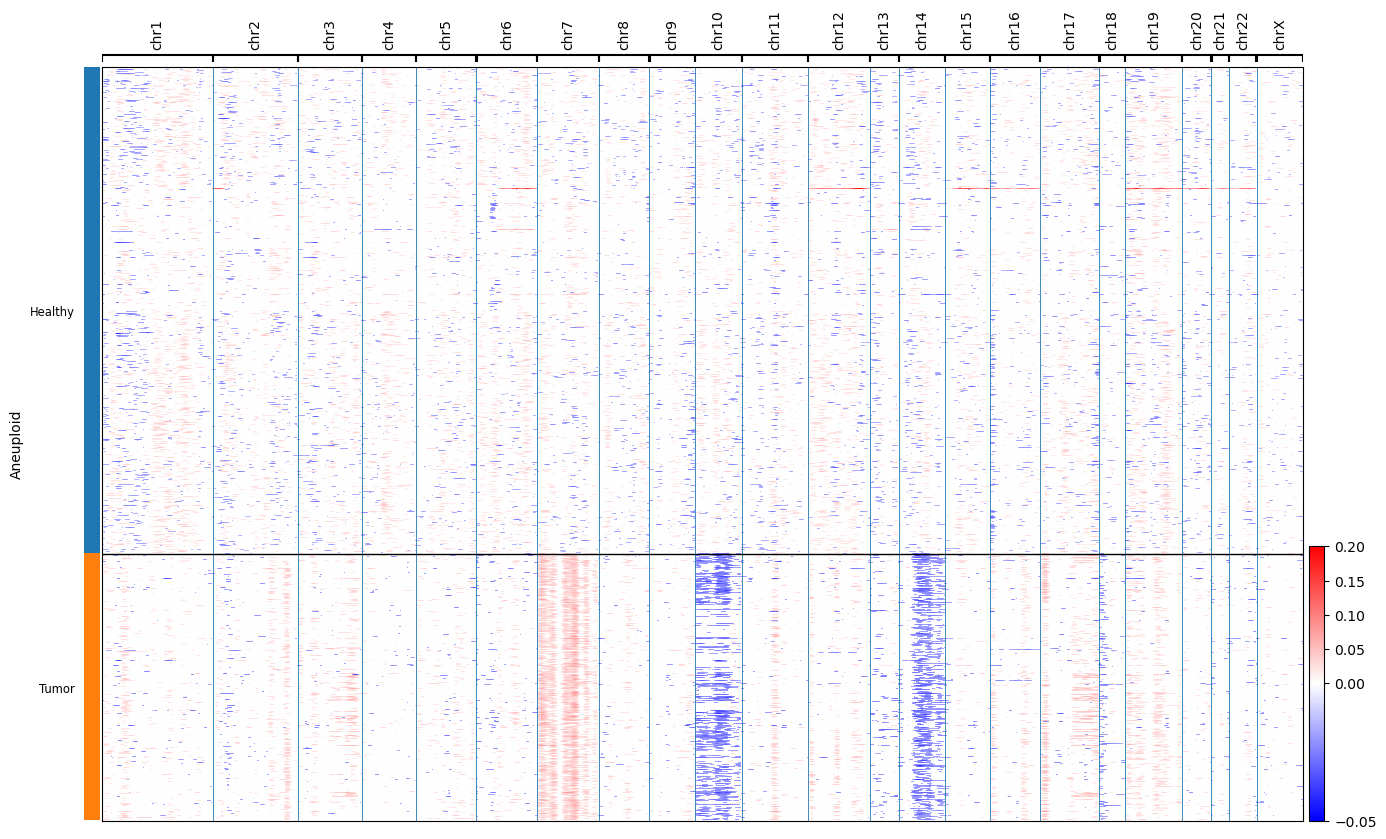

In [97]:
cnv.pl.chromosome_heatmap(ad, groupby="Aneuploid", show=False, cmap='bwr',vmin = -0.05, vmax = 0.2)
#plt.savefig("/proj/cytograph/jesper/Figures/Fig1_SL040/SL040_inferCNV_ln.pdf", dpi=300, bbox_inches="tight")

### Select Colors of choice tSNE cell types (Extended fig 1d)

In [43]:
labels2 = [
    'Monocytes',
    'Macrophages',
    'moTAM',
    'mgTAM',
    'Microglia',
    'Oligodendrocytes',
    'Astrocytes',
    'Tumor',
    'Other']

In [44]:
Right_order = ['Monocytes','Macrophages','MoTAM','MgTAM','Microglia','Oligodendrocytes','Astrocytes']

In [45]:
Z =["#a580ad",
    "#c7bd80",
[0.99609375, 0.796875, 0.59765625],
 "#b36305", 
"#ee7c0e",
"#000000",
'#4574b3',
 "#74c493", 
'#848584'
]

In [95]:
cnv.tl.infercnv(ad, window_size=500, exclude_chromosomes=('', 'GL000009.2', 'GL000194.1', 'GL000195.1', 'GL000205.2',
       'GL000213.1', 'GL000216.2', 'GL000218.1', 'GL000219.1',
       'GL000220.1', 'GL000225.1', 'KI270442.1', 'KI270711.1',
       'KI270713.1', 'KI270721.1', 'KI270726.1', 'KI270727.1',
       'KI270728.1', 'KI270731.1', 'KI270733.1', 'KI270734.1',
       'KI270744.1', 'KI270750.1','chrM','chrY'), reference_key="ManualAnnotationSL040",reference_cat=["Astrocytes", "Microglia","MgTAM", "Oligodendrocytes", "Endothelial"])

  0%|          | 0/28 [00:00<?, ?it/s]

In [ ]:
col = []
FL = ws.ManualAnnotationSL040[:]
for x in FL:
    if x == 'Monocytes':
        col.append(Z[0])
    elif x == 'Macrophages':
        col.append(Z[1])
    elif x == 'MoTAM':
        col.append(Z[2])
    elif x == 'MgTAM':
        col.append(Z[3])
    elif x == 'Microglia':
        col.append(Z[4])
    elif x == 'Oligodendrocytes':
        col.append(Z[5])
    elif x == 'Astrocytes':
        col.append(Z[6])
    elif x == 'Tumor':
        col.append(Z[7])
    else:
        col.append(Z[8])

In [49]:
palette_classes = {'Astrocytes':'#4574b3',
 'B-cells': [0.0, 0.45703125, 0.859375],
 'Endothelial': [0.59765625, 0.24609375, 0.0],
 'Fibroblasts': [0.296875, 0.0, 0.359375],
 'Macrophages': "#c7bd80",
 'Microglia': "#ee7c0e",
 'MoTAM': [0.99609375, 0.796875, 0.59765625], 
 'MgTAM':  "#b36305",                
 'Monocytes': "#a580ad",
 'OPCs': [0.55859375, 0.484375, 0.0],
 'Oligodendrocytes': "#000000",
 'Pericytes': [0.7578125, 0.0, 0.53125],
 'Tumor': "#74c493",
 'VSMC': [0.99609375, 0.640625, 0.01953125]}

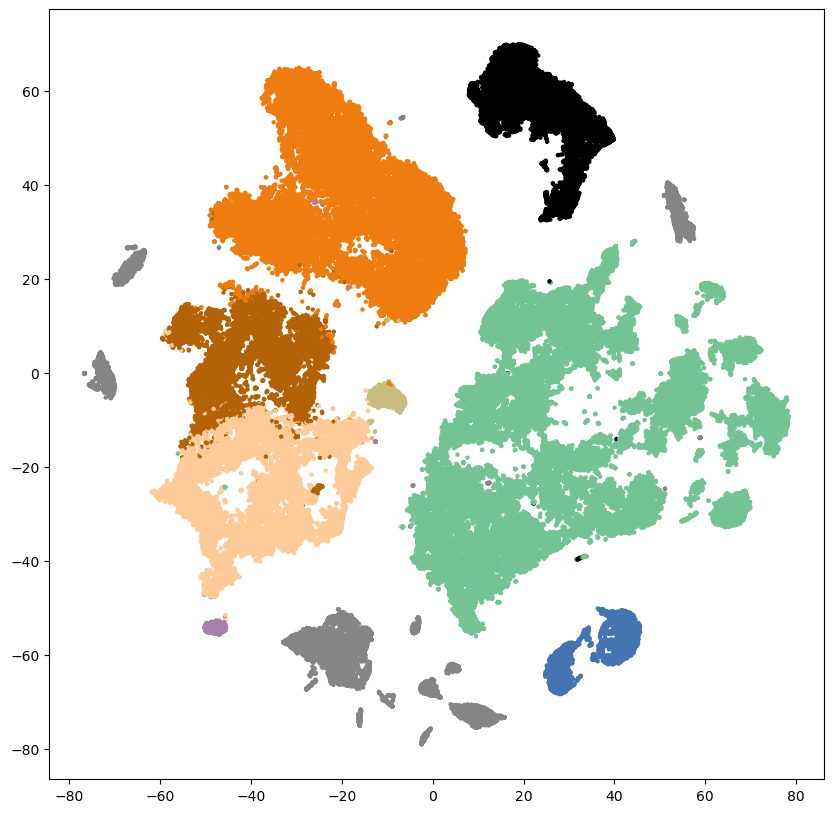

In [50]:
plt.figure(figsize=(10,10))
plt.scatter(ws.Embedding[:, 0], ws.Embedding[:, 1], c=col, s=10, lw=0, rasterized=True)

### Calc Neftel-substates for all cells and plot tSNE (Extended fig 1d)

In [20]:
#https://github.com/linnarsson-lab/cytograph-shoji/blob/main/cytograph/annotation/neftel_states.py
cg.NeftelStates().fit(ws, save=True)

INFO:root:Loading genes
INFO:root:Loading expression matrix
INFO:root:Normalizing to median total UMI
INFO:root:Calculating relative expression
INFO:root:Ordering genes by absolute expression
INFO:root:Computing signature scores
INFO:root: [Creating tensor NeftelClass of shape (135482,)]
INFO:root: [Creating tensor NeftelScore of shape (135482, 4)]


(array([[-5.12207971,  2.92527637, -0.78580633, -1.95661519],
        [-4.75231112,  6.48582729, -0.99332492, -2.41403939],
        [-4.69628196, 13.82130292, -0.85045719, -2.76133894],
        ...,
        [ 3.63762255,  0.53086907,  0.37425555, -0.08754248],
        [ 3.60092521, -2.32503653,  0.45062875,  1.93811526],
        [ 8.08259284, -1.8890592 ,  0.18257584,  1.27595787]]),
 array(['MES', 'MES', 'MES', ..., 'AC', 'AC', 'AC'], dtype='<U3'))

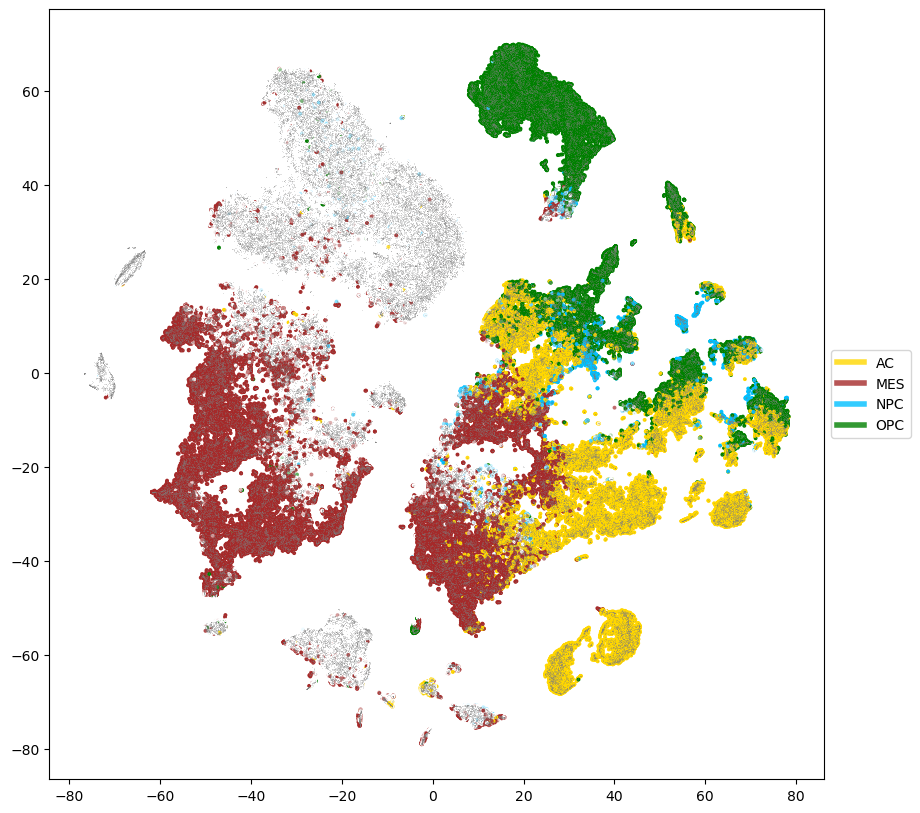

In [31]:
plt.figure(figsize=(10,10))
ac, mes, npc, opc = np.hsplit(ws.NeftelScore[:], 4)
cgplot.scatterm(ws.Embedding[:], c=[ac, mes, npc, opc], cmaps=["gold", "brown", "deepskyblue", "green"], labels=["AC", "MES", "NPC", "OPC"], s=8)
plt.scatter(ws.Embedding[:, 0], ws.Embedding[:, 1], c='gray', alpha=0.2, s=0.4, lw=0, rasterized=True)

### Select colors for sampling locations and plot on tSNE (Extended fig 1d)

In [40]:
Z = ["#ead5c0", # Cortex - gray
 "royalblue", #Periphery - blue
 "#B15297", #Low - purple
"deeppink", #High - pink
 "#000000"] #Necrotic core - black

In [41]:
col = []
FL = ws.Fluorescence[:]
for x in FL:
    if x == 'Cortex':
        col.append(Z[0])
    elif x == 'Periphery':
        col.append(Z[1])
    elif x == 'Low':
        col.append(Z[2])
    elif x == 'High':
        col.append(Z[3])
    else:
        col.append(Z[4])

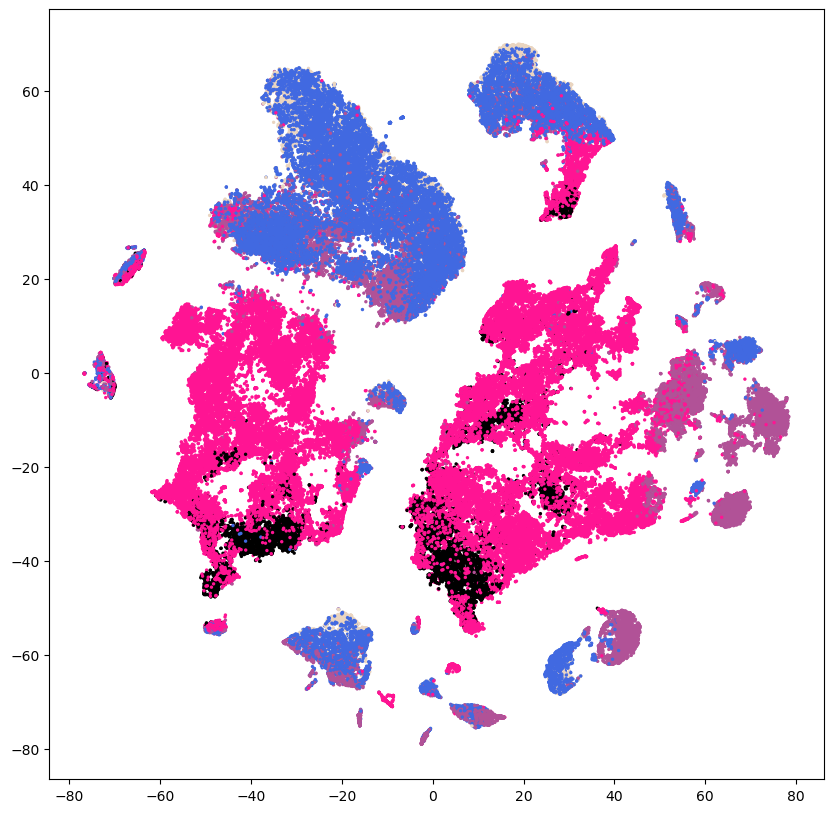

In [42]:
plt.figure(figsize=(10,10))
plt.scatter(ws.Embedding[:, 0], ws.Embedding[:, 1], c=col, s=6, lw=0, rasterized=True)

### Calc fraction of cell types (Extended fig 1e)

CPU times: user 18.4 s, sys: 4.94 s, total: 23.4 s
Wall time: 30.6 s


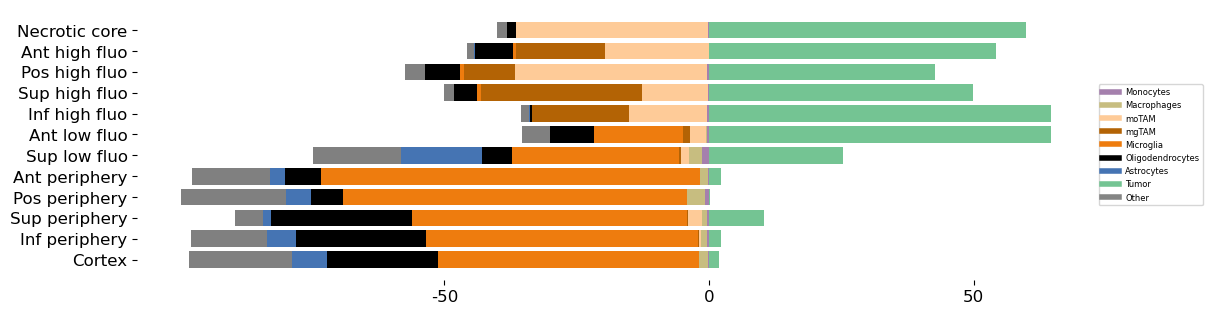

In [72]:
%%time
S = []
Samples = ['Necrotic core',
           'Ant high fluo', 'Pos high fluo','Sup high fluo', 'Inf high fluo',
           'Ant low fluo', 'Sup low fluo',
           'Ant periphery','Pos periphery','Sup periphery','Inf periphery', 
           'Cortex'
          ]
labels = np.unique(ws.ManualAnnotationSL040[:])
Samples = np.flip(Samples)
Samples = np.array(Samples, dtype=object)
unique_samples = Samples
for i, sample in enumerate(Samples):
    Man = ws.ManualAnnotationSL040[:][ws.Location[:] == sample]
    Sum = []
    for x in labels:
        Sum.append(np.sum(np.isin(Man, x)))
    Percent = []
    tot = np.sum(Sum)
    for x in Sum:
        roundedNumber = round(x/tot * 100, 3)
        Perc = str(roundedNumber) + "%"
        Percent.append(roundedNumber)
    size = np.array(Percent)
    S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
nontumor_bars = df.drop(['B-cells','Endothelial','Fibroblasts','NK, T-cells','OPCs','Pericytes','VSMC','Tumor'], axis=1)
other_bars = df[['B-cells','Endothelial','Fibroblasts','NK, T-cells','OPCs','Pericytes','VSMC']]
tumor_bars = df[["Tumor"]]
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(10, len(Samples)*0.25))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([-50,0,50])
ax1.xaxis.set_visible(True)  
ax1.set_xticklabels([-50,0,50],fontsize=12)

for i, ct in enumerate(Right_order):
    ax1.barh(unique_samples,height=0.8, width=-nontumor_bars[ct],left=-left, color=palette_classes[ct])
    left += nontumor_bars[ct]
for i, ct in enumerate(other_bars):
    ax1.barh(unique_samples,height=0.8, width=-other_bars[ct],left=-left, color=[0.5, 0.5, 0.5])
    left += other_bars[ct]
for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=palette_classes[ct])
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in Z]
ax1.legend(hidden_lines,labels2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12) 
None

### Tumor cells, subtype fraction (Extended fig 1e)

CPU times: user 18.5 s, sys: 5.08 s, total: 23.6 s
Wall time: 30.9 s


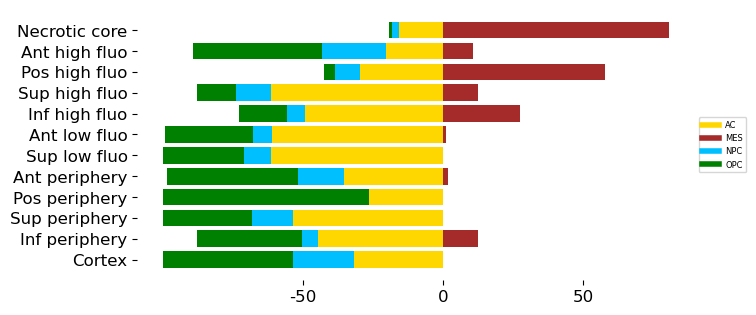

In [82]:
%%time
S = []
#Samples = np.unique(ws.Zone[:])
Samples = ['Necrotic core',
           'Ant high fluo', 'Pos high fluo','Sup high fluo', 'Inf high fluo',
           'Ant low fluo', 'Sup low fluo',
           'Ant periphery','Pos periphery','Sup periphery','Inf periphery', 
           'Cortex'
          ]
Samples = np.flip(Samples)
unique_samples = Samples
Samples = np.array(Samples, dtype=object)
A = ['AC', 'MES', 'NPC', 'OPC']
labels = np.array(A, dtype=object)
for i, sample in enumerate(Samples):
    ac, mes, npc, opc = np.hsplit(ws.NeftelScore[ws.Location[:] == sample][ws.ManualAnnotationSL040[ws.Location[:] == sample] == 'Tumor'], 4)
    winnersAll = np.argmax([ac, mes, npc, opc], axis=0)
    Man = np.hstack(labels[winnersAll])
    Sum = []
    for x in labels:
        Sum.append(np.sum(np.isin(Man, x)))
    Percent = []
    tot = np.sum(Sum)
    for x in Sum:
        roundedNumber = round(x/tot * 100, 3)
        Perc = str(roundedNumber) + "%"
        Percent.append(roundedNumber)
    size = np.array(Percent)
    S.append(size)
df = pd.DataFrame(S, columns=labels,  index=unique_samples)
nontumor_bars = df.drop('MES', axis=1)
tumor_bars = df[["MES"]]
left = np.zeros(len(unique_samples))
fig, ax1 = plt.subplots(figsize=(6, len(Samples)*0.25))
fig.tight_layout(pad=0)
ax1.spines[['top','bottom','left', 'right']].set_visible(False)
ax1.set_xticks([-50,0,50])
ax1.xaxis.set_visible(True) 

ax1.set_xticklabels([-50,0,50],fontsize=12)
colors=["gold", "brown", "deepskyblue", "green"]
pcolors = dict(zip(labels, colors))

for i, ct in enumerate(nontumor_bars):
    ax1.barh(unique_samples,height=0.8, width=-nontumor_bars[ct],left=-left, color=pcolors[ct])
    left += nontumor_bars[ct]
for i, ct in enumerate(tumor_bars):
    ax1.barh(unique_samples, height=0.8, width=tumor_bars[ct],left=0, color=pcolors[ct])
hidden_lines = [Line2D([0], [0], color=clr, lw=4) for clr in colors]
ax1.legend(hidden_lines,labels, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=6)
ax1.set_yticklabels(unique_samples, fontsize=12) 
None

### % MES UMI contribution to total transcriptome across cell types and zones (Extended fig 1f)

In [1]:
celltype = ['Astrocytes',
 'Endothelial',
 'Macrophages',
 'Microglia',    
 'Monocytes',
 'OPCs',
 'Oligodendrocytes',
 'Tumor']

In [21]:
#Calc fraction of UMIs from MES genes in cell types across zones
%%time
ws = db.builds.jesper.h5ad.GBM_SL040
MES = gene_list
Fraction = []
for cell in celltype:
    cMES = 0
    nMES = 0
    hMES = 0
    lMES = 0
    pMES = 0
    if np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Necrotic core'] == cell) < 15:
        nMES = np.nan
        Total_n = np.nan
    else:
        Total_n = np.sum(ws.TotalUMIs[:][ws.Fluorescence[:] == 'Necrotic core'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Necrotic core'] == cell])
        for gene in MES:
            nMES = nMES + np.sum(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == 'Necrotic core'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Necrotic core'] == cell])
    if np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'High'] == cell) < 15:
        hMES = np.nan
        Total_h = np.nan
    else:
        Total_h = np.sum(ws.TotalUMIs[:][ws.Fluorescence[:] == 'High'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'High'] == cell])
        for gene in MES:
            hMES = hMES + np.sum(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == 'High'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'High'] == cell])
    if np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Low'] == cell) < 15:
        lMES = np.nan
        Total_l = np.nan
    else:    
        Total_l = np.sum(ws.TotalUMIs[:][ws.Fluorescence[:] == 'Low'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Low'] == cell])
        for gene in MES:
            lMES = lMES + np.sum(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == 'Low'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Low'] == cell])
    if np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Periphery'] == cell) < 15:
        pMES = np.nan
        Total_p = np.nan
    else:   
        Total_p = np.sum(ws.TotalUMIs[:][ws.Fluorescence[:] == 'Periphery'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Periphery'] == cell])
        for gene in MES:
            pMES = pMES + np.sum(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == 'Periphery'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Periphery'] == cell])
    if np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Cortex'] == cell) < 15:
        cMES = np.nan
        Total_c = np.nan
    else:   
        Total_c = np.sum(ws.TotalUMIs[:][ws.Fluorescence[:] == 'Cortex'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Cortex'] == cell])
        for gene in MES:
            cMES = cMES + np.sum(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == 'Cortex'][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == 'Cortex'] == cell])
    Fraction.append([nMES/Total_n,hMES/Total_h,lMES/Total_l, pMES/Total_p, cMES/Total_c])

CPU times: user 1h 56min 50s, sys: 31min 21s, total: 2h 28min 11s
Wall time: 3h 39min 2s


In [22]:
r = dict(zip(celltype, Fraction))
df = pd.DataFrame(r)
df = df.transpose()
df = df.rename(columns={0:"necrotic core", 1:"high", 2: "low", 3: "Periphery", 4: 'Cortex'}) 
df = df.multiply(100)
merg = df
df

,necrotic core,high,low,Periphery,Cortex
Astrocytes,NaN,11.075270,5.224462,2.811736,2.270910
Endothelial,NaN,4.026932,4.602787,3.346023,3.207619
Macrophages,13.311955,10.171339,7.628568,5.357856,2.522639
Microglia,NaN,7.122843,3.623755,2.548402,2.426639
Monocytes,4.212841,3.925778,3.562615,2.859624,2.829429
OPCs,NaN,4.140583,1.431501,0.691177,0.556746
Oligodendrocytes,3.884189,2.615107,1.318626,0.945555,0.709432
Tumor,12.507291,5.767425,1.647717,1.006576,0.704087


### Colors of choice (Extended fig 1f)

In [24]:
#Colors of choice
palette_classes = {'Astrocytes':'#4574b3',
 'B-cells': [0.0, 0.45703125, 0.859375],
 'Endothelial': [0.59765625, 0.24609375, 0.0],
 'Macrophages': "#c7bd80",
 'Microglia': "#ee7c0e",
 'MoTAM': [0.99609375, 0.796875, 0.59765625], 
 'MgTAM':  "#b36305",                
 'Monocytes': "#a580ad",
 'OPCs': [0.55859375, 0.484375, 0.0],
 'Oligodendrocytes': "#000000",
 'Tumor': "#74c493"}

In [31]:
#Show cells with clear decrease
select = df.drop(df.index[[1,4]])
merg = select
select

,necrotic core,high,low,Periphery,Cortex
Astrocytes,NaN,11.075270,5.224462,2.811736,2.270910
Macrophages,13.311955,10.171339,7.628568,5.357856,2.522639
Microglia,NaN,7.122843,3.623755,2.548402,2.426639
OPCs,NaN,4.140583,1.431501,0.691177,0.556746
Oligodendrocytes,3.884189,2.615107,1.318626,0.945555,0.709432
Tumor,12.507291,5.767425,1.647717,1.006576,0.704087


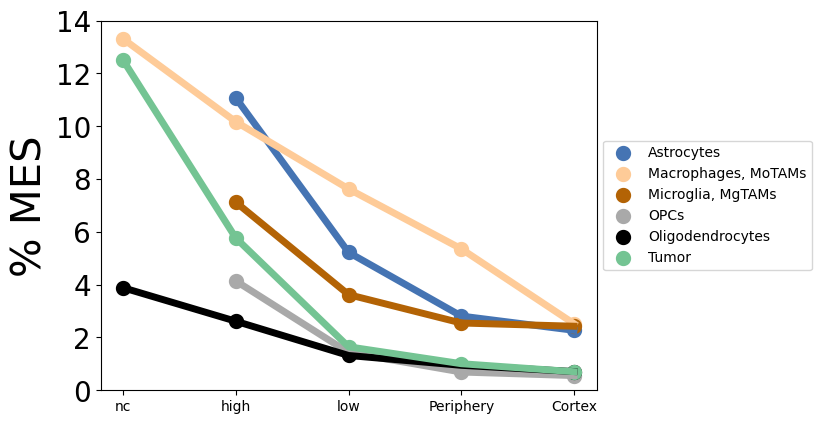

In [33]:
numb = merg.columns
numb = ['nc', 'high', 'low', 'Periphery','Cortex'] # nc = Necrotic core
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='#4574b3',linewidth=5)
plt.scatter(numb, merg.iloc[1],label=('Macrophages, MoTAMs'), color=[0.99609375, 0.796875, 0.59765625],linewidth=5)
plt.scatter(numb, merg.iloc[2],label=('Microglia, MgTAMs'), color="#b36305",linewidth=5)
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color= 'darkgrey',linewidth=5)
plt.scatter(numb, merg.iloc[4],label=(merg.index[4]), color="#000000",linewidth=5)
plt.scatter(numb, merg.iloc[5],label=(merg.index[5]), color="#74c493",linewidth=5)

plt.plot(numb, merg.iloc[0], color='#4574b3', linewidth=5)
plt.plot(numb, merg.iloc[1], color=[0.99609375, 0.796875, 0.59765625],linewidth=5)
plt.plot(numb, merg.iloc[2], color= "#b36305",linewidth=5) 
plt.plot(numb, merg.iloc[3], color='darkgrey',linewidth=5)
plt.plot(numb, merg.iloc[4], color="#000000",linewidth=5)
plt.plot(numb, merg.iloc[5], color="#74c493",linewidth=5)

plt.ylim(0, 14)
plt.legend(loc='center left',bbox_to_anchor=(1, 0.5))
plt.ylabel('% MES', fontsize=30)
plt.xticks(numb)
plt.yticks(fontsize=20)
None

In [34]:
#Show cells with no or minimal decrease
select2 = df.drop(df.index[[0,2,3,5,6,7]])
merg = select2
select2

,necrotic core,high,low,Periphery,Cortex
Endothelial,NaN,4.026932,4.602787,3.346023,3.207619
Monocytes,4.212841,3.925778,3.562615,2.859624,2.829429


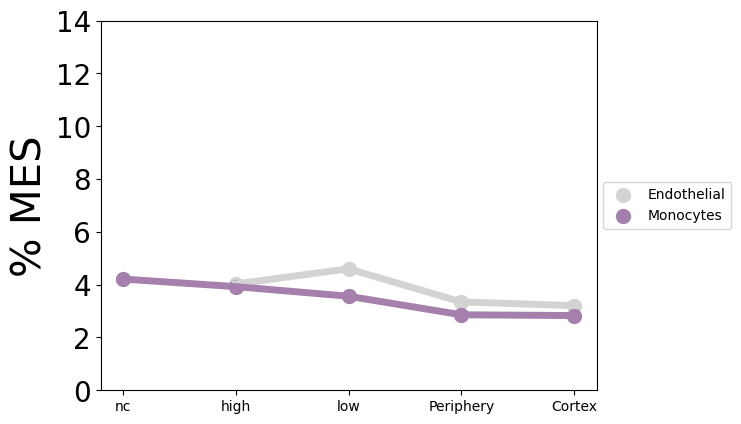

In [30]:
merg = select2
numb = merg.columns
numb = ['nc', 'high', 'low', 'Periphery','Cortex'] # nc = Necrotic core
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='lightgrey',linewidth=5)
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color="#a580ad",linewidth=5)
plt.plot(numb, merg.iloc[0], color='lightgrey', linewidth=5)
plt.plot(numb, merg.iloc[1], color="#a580ad",linewidth=5)
plt.ylim(0, 14)
plt.legend(loc='center left',bbox_to_anchor=(1, 0.5))
#plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES', fontsize=30)
#plt.title('Cell types', fontsize=25)
plt.xticks(numb)
plt.yticks(fontsize=20)
None

### Colormap for Macrophage-lineage (Macrophages, moTAMs) across all MES-genes and zones (Extended fig 1g)

CPU times: user 14min 15s, sys: 3min 46s, total: 18min 2s
Wall time: 24min 5s


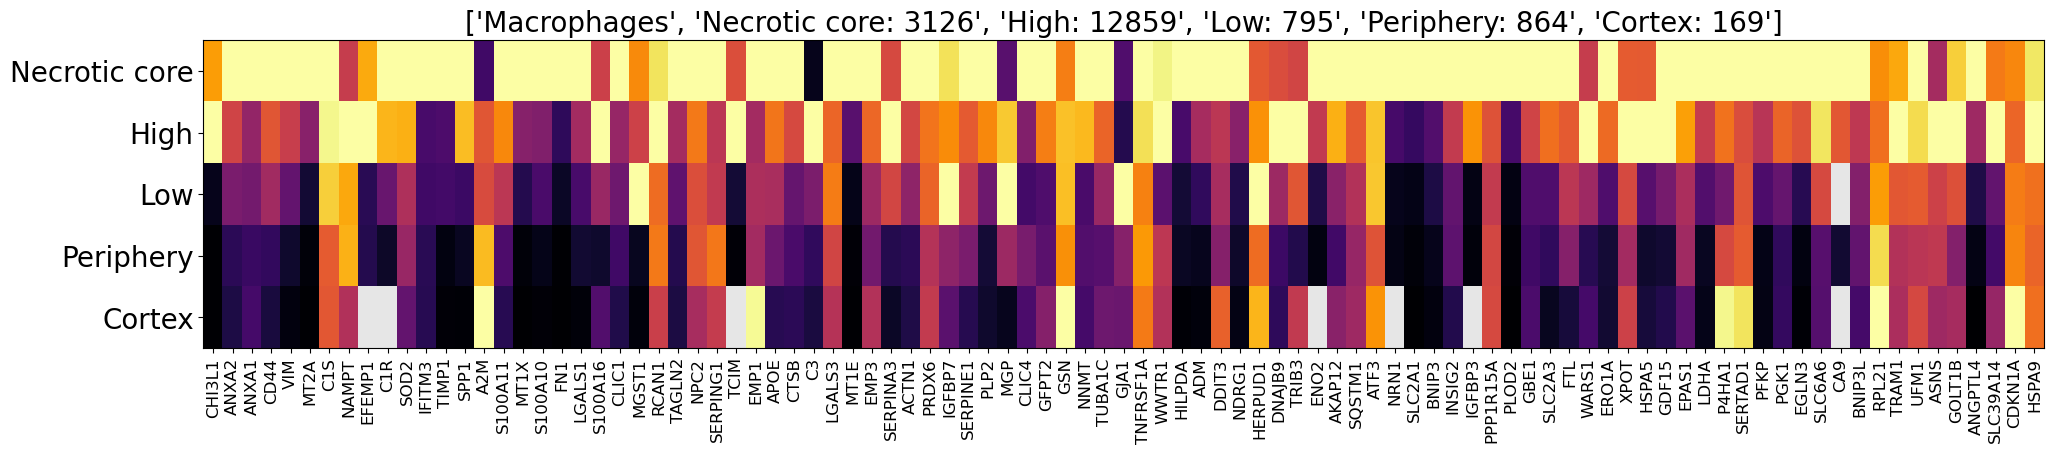

In [86]:
%%time
celltype = ['Macrophages']
Samples = ['Necrotic core', 'High', 'Low', 'Periphery','Cortex']
for cell in celltype:
    Sum = [cell]
    unique_samples = []
    for i, sample in enumerate(Samples):
        Su = np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == sample] == cell)
        Sum.append(sample + ": " + str(Su))
        if Su > 0:
            unique_samples.append(sample)
    n_genes = len(gene_list)
    n_clusters = len(Samples)
    x = np.zeros((n_genes, n_clusters))
    for i, gene in enumerate(gene_list):
        gene_ix = np.where(ws.Gene[:] == gene)[0][0]
        for n, sample in enumerate(Samples):
            x[i, n] = np.mean(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == sample][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == sample] == 'Macrophages'])

    # Normalize
    totals = x.sum(axis=1)
    xY = (x.T / totals * np.median(totals)).T
    xY = cg.div0(xY.T, np.percentile(xY, 99.5, axis=1)).T

    # Make background grey for zeros
    xY = xY.T
    bg = np.zeros_like(xY) + 0.9
    xY = np.ma.masked_where(xY == 0, xY)
    plt.figure(None, (n_genes / 4, 4))
    plt.imshow(bg[:], vmin=0, vmax=1, cmap=plt.cm.gray, aspect="auto")
    plt.imshow(xY[:], cmap="inferno",vmin=0, vmax=1, interpolation="nearest", aspect="auto", alpha=1)
    plt.xticks(ticks=range(n_genes),labels=gene_list, fontsize=12, rotation=90)
    plt.yticks(ticks=range(n_clusters), labels=Samples, fontsize=20)
    plt.title(list(Sum),fontsize=20)
    None

### Colormap for Microglia-lineage (Microglia, mgTAMs) across all MES-genes and zones (Extended fig 1g)

CPU times: user 11min 44s, sys: 3min 8s, total: 14min 53s
Wall time: 19min 41s


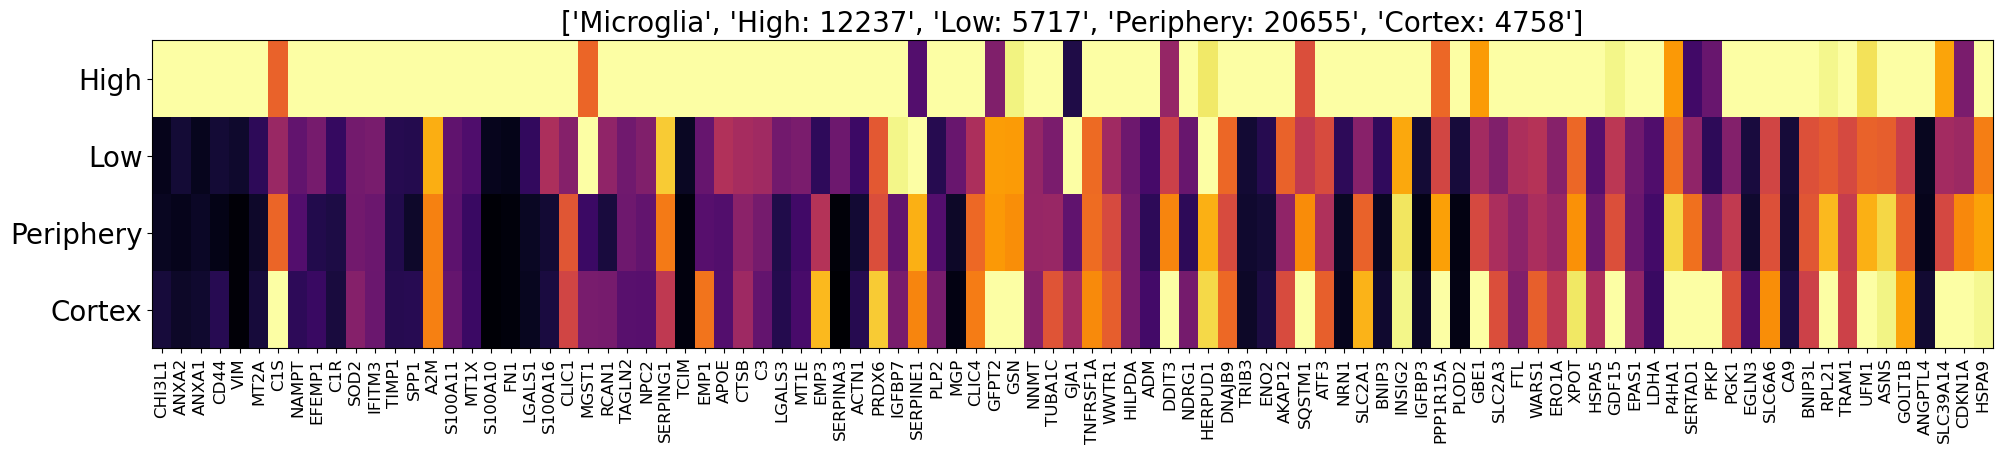

In [88]:
%%time
#TAM with cortex inferno
#celltype = np.unique(ws.ManualAnnotationSL040[:])
#Samples = ['Ant high fluo', 'Ant low fluo', 'Ant no fluo'] 
celltype = ['Microglia']
Samples = ['High', 'Low', 'Periphery','Cortex']
for cell in celltype:
    Sum = [cell]
    unique_samples = []
    for i, sample in enumerate(Samples):
        Su = np.sum(ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == sample] == cell)
        Sum.append(sample + ": " + str(Su))
        if Su > 0:
            unique_samples.append(sample)
    n_genes = len(gene_list)
    n_clusters = len(Samples)
    x = np.zeros((n_genes, n_clusters))
    for i, gene in enumerate(gene_list):
        gene_ix = np.where(ws.Gene[:] == gene)[0][0]
        for n, sample in enumerate(Samples):
            x[i, n] = np.mean(ws.Expression[:, ws.Gene == str(gene)][ws.Fluorescence[:] == sample][ws.ManualAnnotationSL040_Myeloid[ws.Fluorescence[:] == sample] == 'Microglia'])

    # Normalize
    totals = x.sum(axis=1)
    xY = (x.T / totals * np.median(totals)).T
    xY = cg.div0(xY.T, np.percentile(xY, 99.5, axis=1)).T

    # Make background grey for zeros
    xY = xY.T
    bg = np.zeros_like(xY) + 0.9
    xY = np.ma.masked_where(xY == 0, xY)
    plt.figure(None, (n_genes / 4, 4))
    plt.imshow(bg[:], vmin=0, vmax=1, cmap=plt.cm.gray, aspect="auto")
    plt.imshow(xY[:], cmap="inferno",vmin=0, vmax=1, interpolation="nearest", aspect="auto", alpha=1)
    plt.xticks(ticks=range(n_genes),labels=gene_list, fontsize=12, rotation=90)
    plt.yticks(ticks=range(n_clusters), labels=Samples, fontsize=20)
    plt.title(list(Sum),fontsize=20)
    None